<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/Work/Orders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-6-deccddb01d92>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
<ipython-input-6-deccddb01d92>:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')



Basic Statistics:
             ROWID       ORDERID                      ORDERDATE  \
count  8399.000000   8399.000000                           8399   
mean   4200.000000  29965.179783  2010-12-25 00:40:58.578402048   
min       1.000000      3.000000            2009-01-01 00:00:00   
25%    2100.500000  15011.500000            2009-12-20 00:00:00   
50%    4200.000000  29857.000000            2010-12-17 00:00:00   
75%    6299.500000  44596.000000            2012-01-01 12:00:00   
max    8399.000000  59973.000000            2012-12-30 00:00:00   
std    2424.726789  17260.883447                            NaN   

       ORDERQUANTITY         SALES     DISCOUNT        PROFIT    UNITPRICE  \
count    8399.000000   8399.000000  8399.000000   8399.000000  8399.000000   
mean       25.571735   1775.878179     0.049671    181.184424    89.346259   
min         1.000000      2.240000     0.000000 -14140.700000     0.990000   
25%        13.000000    143.195000     0.020000    -83.315000    

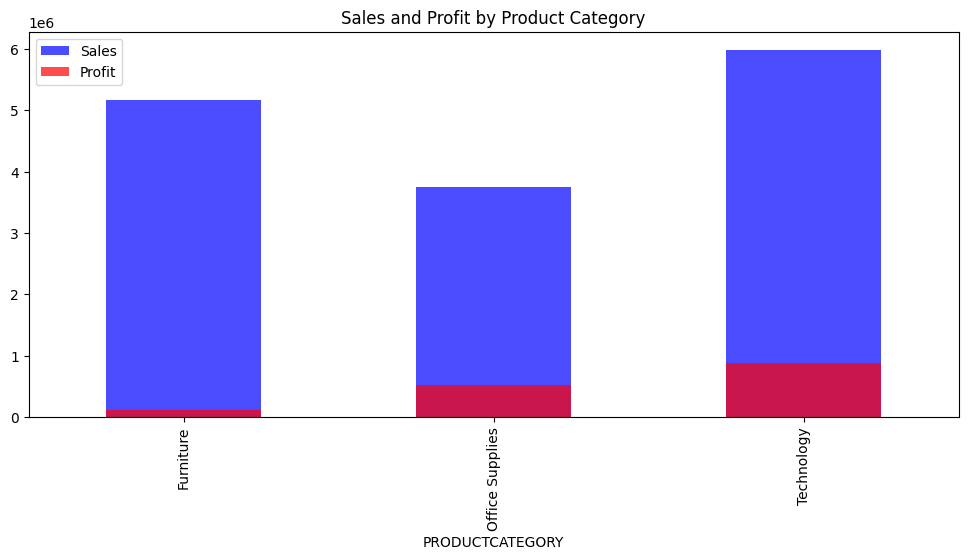

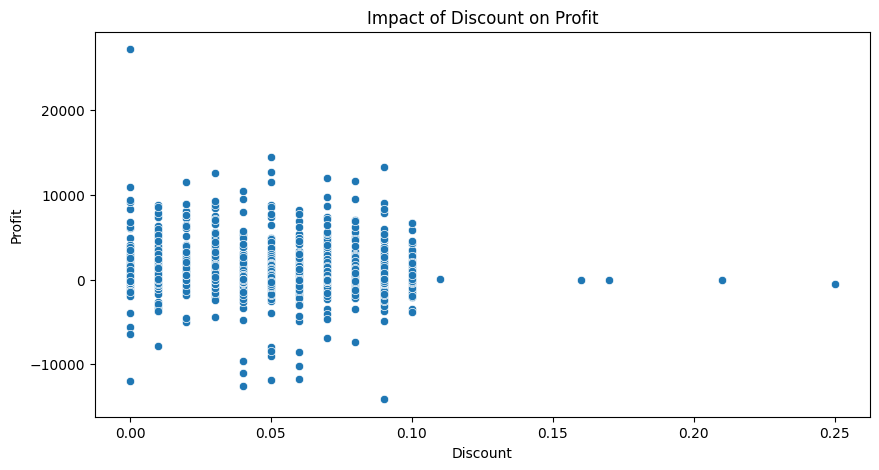

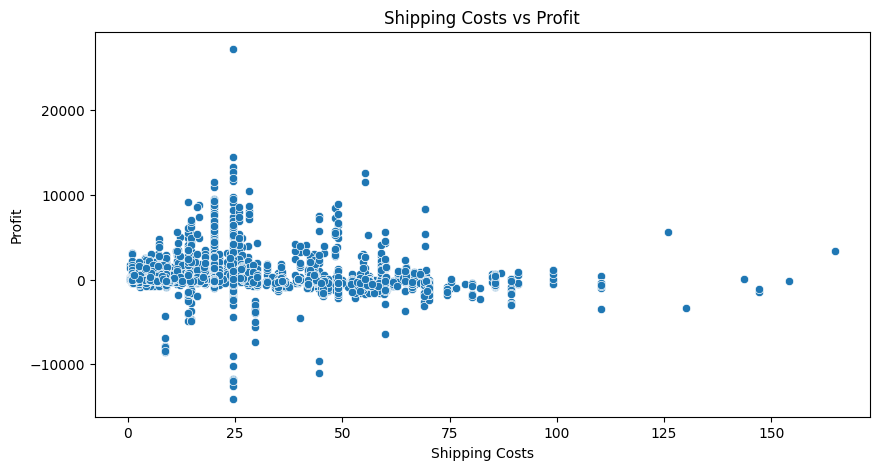


Sales Forecasting Model Performance:
MAE: 1287.4043830191888
R2 Score: 0.4391231877817856


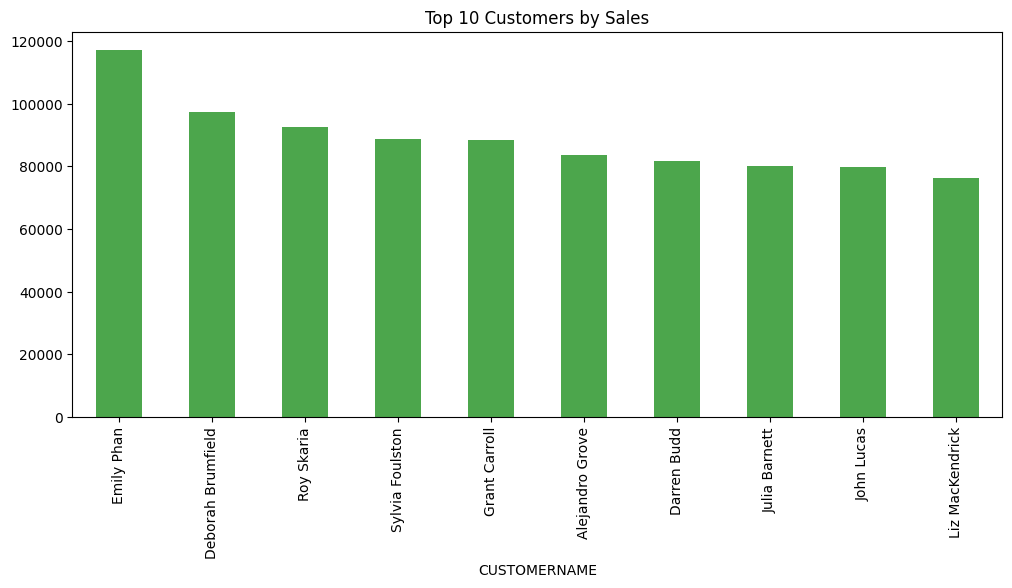

<ipython-input-6-deccddb01d92>:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')


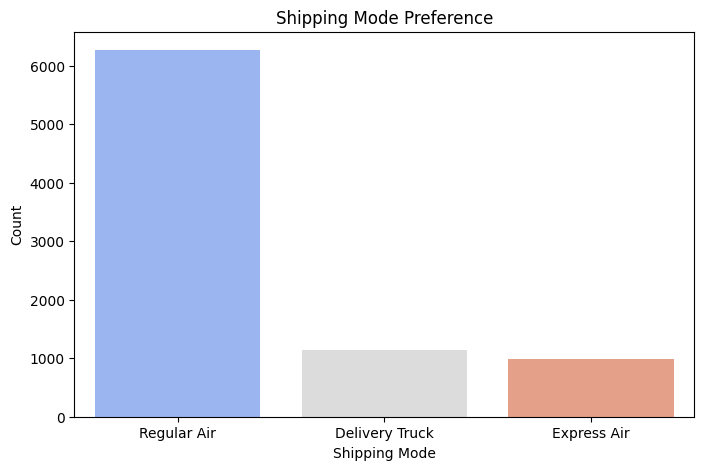


Analysis Complete!🚀


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import chardet

# Detect file encoding
file_path = 'ORDERS.csv'  # Update the path accordingly
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read(100000))  # Read first 100KB to guess encoding
    detected_encoding = result['encoding']

# Load dataset with detected encoding
df = pd.read_csv(file_path, encoding=detected_encoding)

# Convert date columns to datetime format
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')

# Summary statistics
print("\nBasic Statistics:")
print(df.describe())

# Sales and Profit Analysis
sales_by_category = df.groupby('PRODUCTCATEGORY')['SALES'].sum()
profit_by_category = df.groupby('PRODUCTCATEGORY')['PROFIT'].sum()

# Visualizing Sales & Profit
plt.figure(figsize=(12,5))
sales_by_category.plot(kind='bar', color='blue', alpha=0.7, label='Sales')
profit_by_category.plot(kind='bar', color='red', alpha=0.7, label='Profit')
plt.title("Sales and Profit by Product Category")
plt.legend()
plt.show()

# Discount Impact on Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['DISCOUNT'], y=df['PROFIT'])
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# Shipping Cost vs. Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['SHIPPINGCOSTS'], y=df['PROFIT'])
plt.title("Shipping Costs vs Profit")
plt.xlabel("Shipping Costs")
plt.ylabel("Profit")
plt.show()

# Predictive Sales Forecasting
X = df[['ORDERQUANTITY', 'UNITPRICE', 'DISCOUNT', 'SHIPPINGCOSTS']]
y = df['SALES']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Performance
print("\nSales Forecasting Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Customer Segmentation Analysis
customer_sales = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False)
top_customers = customer_sales.head(10)

plt.figure(figsize=(12,5))
top_customers.plot(kind='bar', color='green', alpha=0.7)
plt.title("Top 10 Customers by Sales")
plt.show()

# Shipping Mode Preference Analysis
ship_mode_counts = df['SHIPMODE'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')
plt.title("Shipping Mode Preference")
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.show()

print("\nAnalysis Complete!🚀")

<ipython-input-7-38ede57be925>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
<ipython-input-7-38ede57be925>:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')



Basic Statistics:
             ROWID       ORDERID                      ORDERDATE  \
count  8399.000000   8399.000000                           8399   
mean   4200.000000  29965.179783  2010-12-25 00:40:58.578402048   
min       1.000000      3.000000            2009-01-01 00:00:00   
25%    2100.500000  15011.500000            2009-12-20 00:00:00   
50%    4200.000000  29857.000000            2010-12-17 00:00:00   
75%    6299.500000  44596.000000            2012-01-01 12:00:00   
max    8399.000000  59973.000000            2012-12-30 00:00:00   
std    2424.726789  17260.883447                            NaN   

       ORDERQUANTITY         SALES     DISCOUNT        PROFIT    UNITPRICE  \
count    8399.000000   8399.000000  8399.000000   8399.000000  8399.000000   
mean       25.571735   1775.878179     0.049671    181.184424    89.346259   
min         1.000000      2.240000     0.000000 -14140.700000     0.990000   
25%        13.000000    143.195000     0.020000    -83.315000    

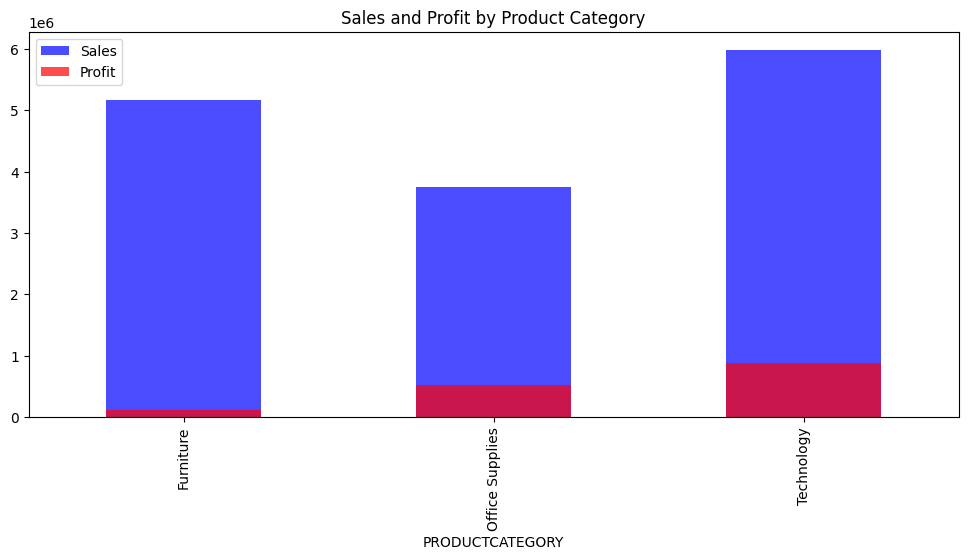

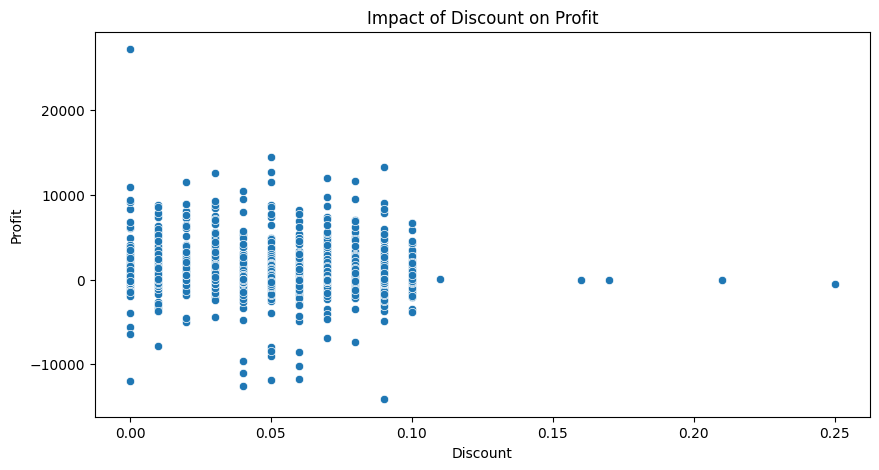

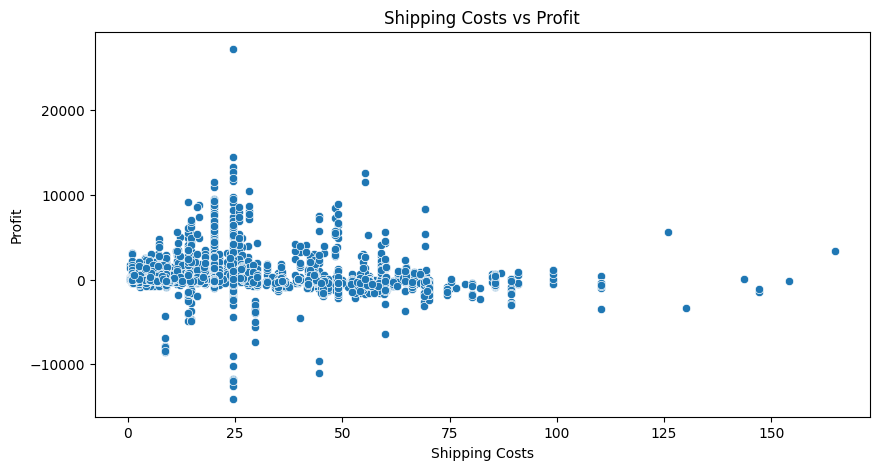


Sales Forecasting Model Performance:
MAE: 1287.4043830191888
R2 Score: 0.4391231877817856

Top Performing Regions by Sales:
REGION
West        3.597549e+06
Ontario     3.063212e+06
Prarie      2.837305e+06
Atlantic    2.014248e+06
Quebec      1.510195e+06
Name: SALES, dtype: float64

Top Performing Regions by Profit:
REGION
Ontario     346868.54
Prarie      321160.12
West        297008.61
Atlantic    238960.66
Quebec      140426.65
Name: PROFIT, dtype: float64


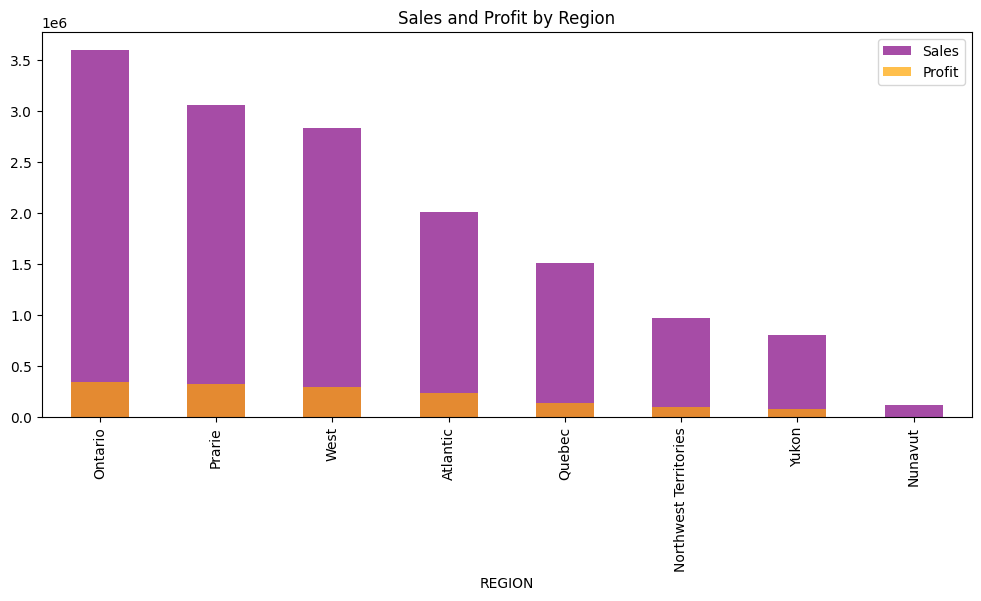

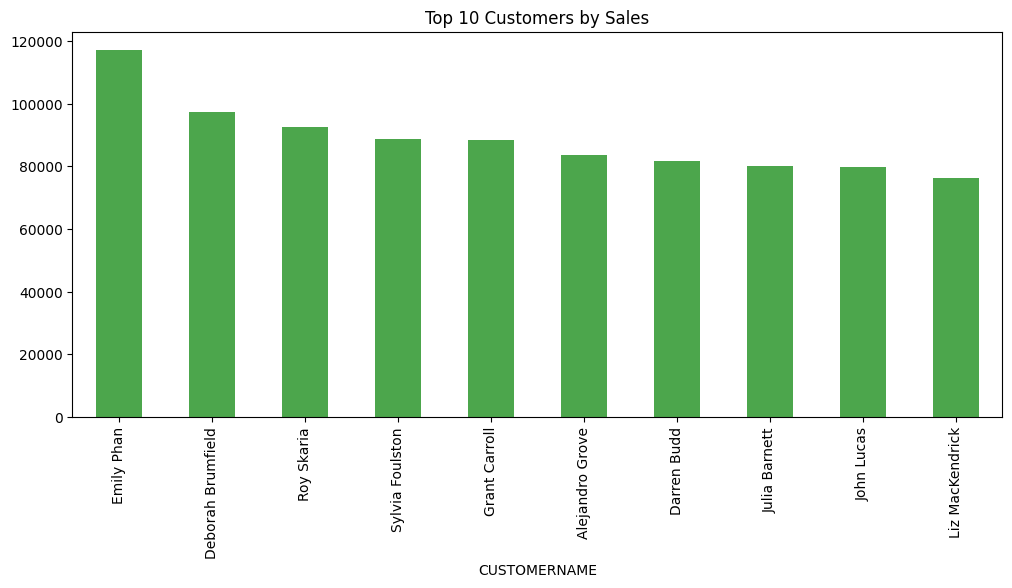

<ipython-input-7-38ede57be925>:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')


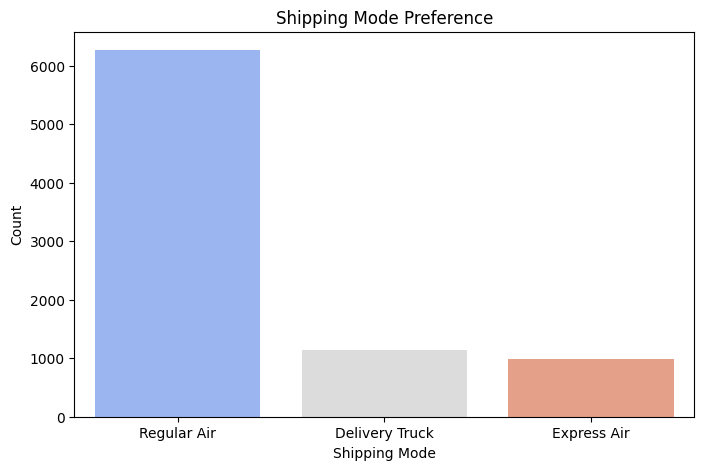


Analysis Complete!🚀


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import chardet

# Detect file encoding
file_path = 'ORDERS.csv'  # Update the path accordingly
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read(100000))  # Read first 100KB to guess encoding
    detected_encoding = result['encoding']

# Load dataset with detected encoding
df = pd.read_csv(file_path, encoding=detected_encoding)

# Convert date columns to datetime format
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')

# Summary statistics
print("\nBasic Statistics:")
print(df.describe())

# Sales and Profit Analysis
sales_by_category = df.groupby('PRODUCTCATEGORY')['SALES'].sum()
profit_by_category = df.groupby('PRODUCTCATEGORY')['PROFIT'].sum()

# Visualizing Sales & Profit
plt.figure(figsize=(12,5))
sales_by_category.plot(kind='bar', color='blue', alpha=0.7, label='Sales')
profit_by_category.plot(kind='bar', color='red', alpha=0.7, label='Profit')
plt.title("Sales and Profit by Product Category")
plt.legend()
plt.show()

# Discount Impact on Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['DISCOUNT'], y=df['PROFIT'])
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# Shipping Cost vs. Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['SHIPPINGCOSTS'], y=df['PROFIT'])
plt.title("Shipping Costs vs Profit")
plt.xlabel("Shipping Costs")
plt.ylabel("Profit")
plt.show()

# Predictive Sales Forecasting
X = df[['ORDERQUANTITY', 'UNITPRICE', 'DISCOUNT', 'SHIPPINGCOSTS']]
y = df['SALES']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Performance
print("\nSales Forecasting Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Regional Performance Analysis
region_sales = df.groupby('REGION')['SALES'].sum().sort_values(ascending=False)
region_profit = df.groupby('REGION')['PROFIT'].sum().sort_values(ascending=False)

print("\nTop Performing Regions by Sales:")
print(region_sales.head())
print("\nTop Performing Regions by Profit:")
print(region_profit.head())

plt.figure(figsize=(12,5))
region_sales.plot(kind='bar', color='purple', alpha=0.7, label='Sales')
region_profit.plot(kind='bar', color='orange', alpha=0.7, label='Profit')
plt.title("Sales and Profit by Region")
plt.legend()
plt.show()

# Customer Segmentation Analysis
customer_sales = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False)
top_customers = customer_sales.head(10)

plt.figure(figsize=(12,5))
top_customers.plot(kind='bar', color='green', alpha=0.7)
plt.title("Top 10 Customers by Sales")
plt.show()

# Shipping Mode Preference Analysis
ship_mode_counts = df['SHIPMODE'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')
plt.title("Shipping Mode Preference")
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.show()

print("\nAnalysis Complete!🚀")


<ipython-input-8-79bea87f8257>:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
<ipython-input-8-79bea87f8257>:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')



Basic Statistics:
             ROWID       ORDERID                      ORDERDATE  \
count  8399.000000   8399.000000                           8399   
mean   4200.000000  29965.179783  2010-12-25 00:40:58.578402048   
min       1.000000      3.000000            2009-01-01 00:00:00   
25%    2100.500000  15011.500000            2009-12-20 00:00:00   
50%    4200.000000  29857.000000            2010-12-17 00:00:00   
75%    6299.500000  44596.000000            2012-01-01 12:00:00   
max    8399.000000  59973.000000            2012-12-30 00:00:00   
std    2424.726789  17260.883447                            NaN   

       ORDERQUANTITY         SALES     DISCOUNT        PROFIT    UNITPRICE  \
count    8399.000000   8399.000000  8399.000000   8399.000000  8399.000000   
mean       25.571735   1775.878179     0.049671    181.184424    89.346259   
min         1.000000      2.240000     0.000000 -14140.700000     0.990000   
25%        13.000000    143.195000     0.020000    -83.315000    

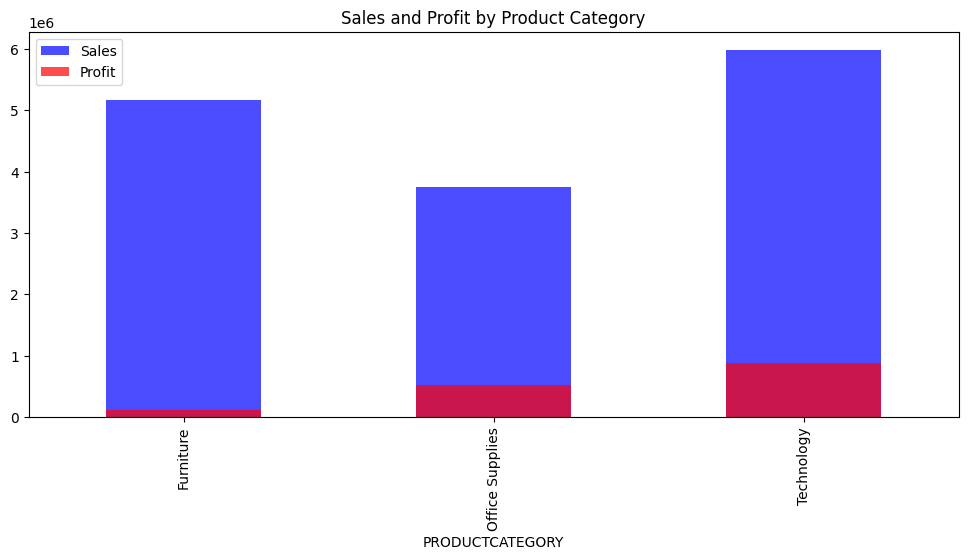

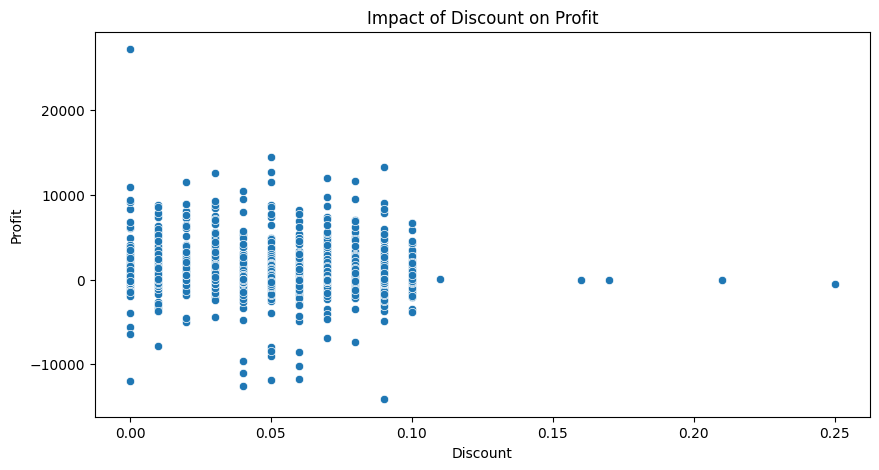

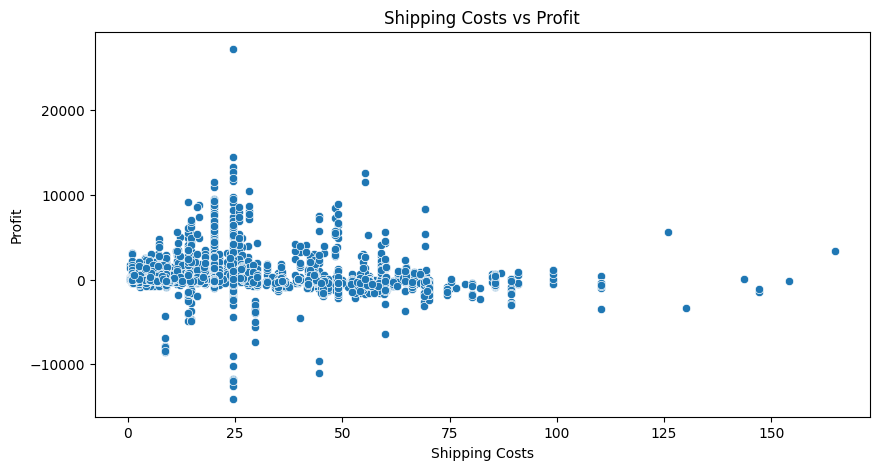


Sales Forecasting Model Performance:
MAE: 1287.4043830191888
R2 Score: 0.4391231877817856

OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                  SALES   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     2380.
Date:                Mon, 10 Feb 2025   Prob (F-statistic):               0.00
Time:                        06:41:13   Log-Likelihood:                -77476.
No. Observations:                8399   AIC:                         1.550e+05
Df Residuals:                    8394   BIC:                         1.550e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------

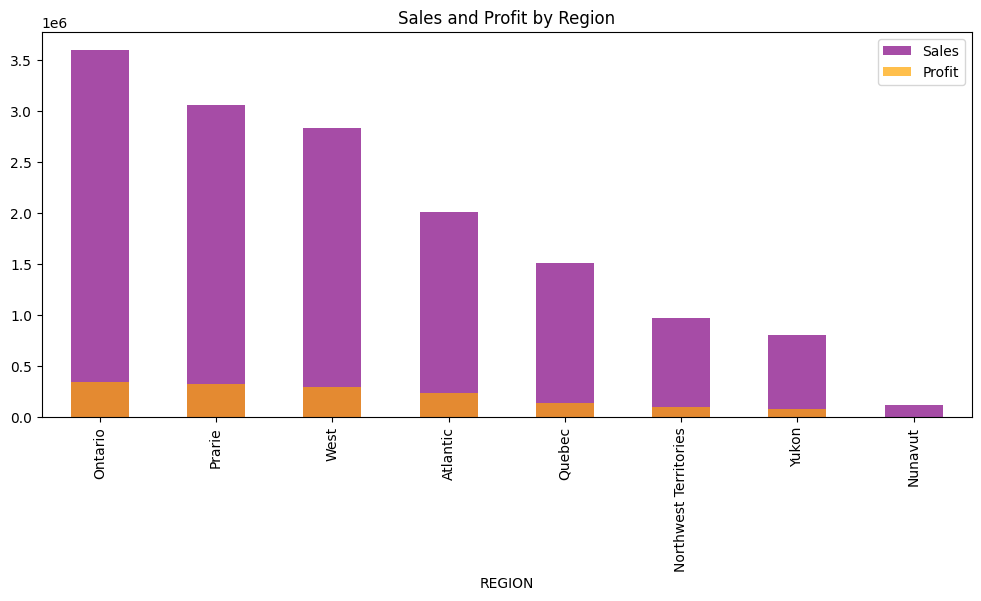

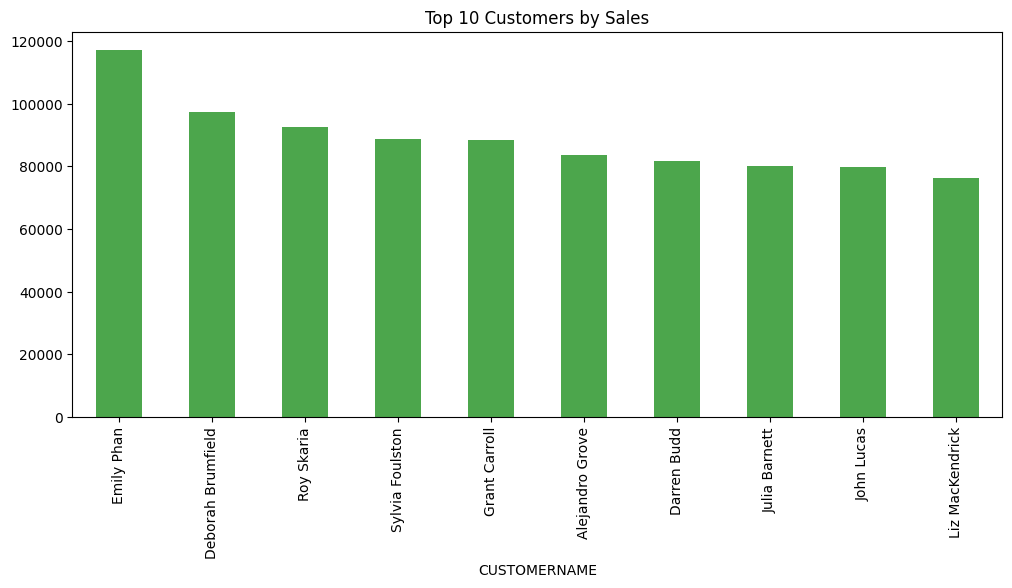

<ipython-input-8-79bea87f8257>:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')


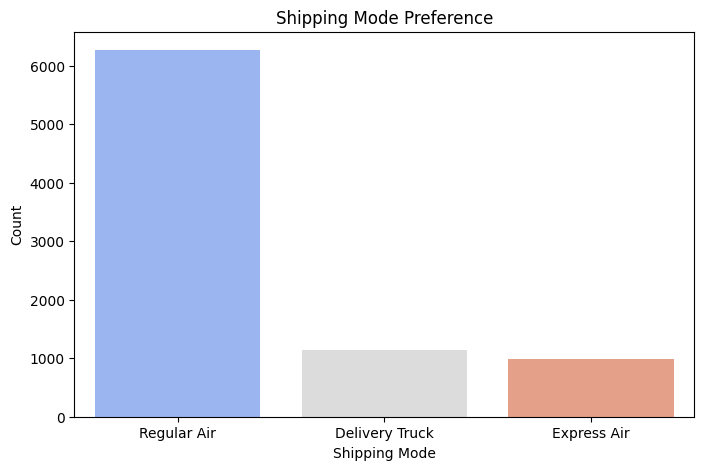


Analysis Complete!🚀


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm
import chardet

# Detect file encoding
file_path = 'ORDERS.csv'  # Update the path accordingly
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read(100000))  # Read first 100KB to guess encoding
    detected_encoding = result['encoding']

# Load dataset with detected encoding
df = pd.read_csv(file_path, encoding=detected_encoding)

# Convert date columns to datetime format
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')
df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'], errors='coerce')

# Summary statistics
print("\nBasic Statistics:")
print(df.describe())

# Sales and Profit Analysis
sales_by_category = df.groupby('PRODUCTCATEGORY')['SALES'].sum()
profit_by_category = df.groupby('PRODUCTCATEGORY')['PROFIT'].sum()

# Visualizing Sales & Profit
plt.figure(figsize=(12,5))
sales_by_category.plot(kind='bar', color='blue', alpha=0.7, label='Sales')
profit_by_category.plot(kind='bar', color='red', alpha=0.7, label='Profit')
plt.title("Sales and Profit by Product Category")
plt.legend()
plt.show()

# Discount Impact on Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['DISCOUNT'], y=df['PROFIT'])
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# Shipping Cost vs. Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['SHIPPINGCOSTS'], y=df['PROFIT'])
plt.title("Shipping Costs vs Profit")
plt.xlabel("Shipping Costs")
plt.ylabel("Profit")
plt.show()

# Predictive Sales Forecasting
X = df[['ORDERQUANTITY', 'UNITPRICE', 'DISCOUNT', 'SHIPPINGCOSTS']]
y = df['SALES']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Performance
print("\nSales Forecasting Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# OLS Regression Analysis
X_ols = sm.add_constant(X)  # Add constant term
ols_model = sm.OLS(y, X_ols).fit()
print("\nOLS Regression Results:")
print(ols_model.summary())

# Regional Performance Analysis
region_sales = df.groupby('REGION')['SALES'].sum().sort_values(ascending=False)
region_profit = df.groupby('REGION')['PROFIT'].sum().sort_values(ascending=False)

print("\nTop Performing Regions by Sales:")
print(region_sales.head())
print("\nTop Performing Regions by Profit:")
print(region_profit.head())

plt.figure(figsize=(12,5))
region_sales.plot(kind='bar', color='purple', alpha=0.7, label='Sales')
region_profit.plot(kind='bar', color='orange', alpha=0.7, label='Profit')
plt.title("Sales and Profit by Region")
plt.legend()
plt.show()

# Customer Segmentation Analysis
customer_sales = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False)
top_customers = customer_sales.head(10)

plt.figure(figsize=(12,5))
top_customers.plot(kind='bar', color='green', alpha=0.7)
plt.title("Top 10 Customers by Sales")
plt.show()

# Shipping Mode Preference Analysis
ship_mode_counts = df['SHIPMODE'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=ship_mode_counts.index, y=ship_mode_counts.values, palette='coolwarm')
plt.title("Shipping Mode Preference")
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.show()

print("\nAnalysis Complete!🚀")


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load dataset
file_path = 'ORDERS.csv'  # Update with actual file path
df = pd.read_csv(file_path, encoding='ISO-8859-1')  # Fix encoding issues if any

# Convert date columns to datetime format
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'])

# Drop unnecessary columns
columns_to_exclude = ['ROWID', 'ORDERID', 'ORDERDATE', 'SHIPDATE', 'CUSTOMERNAME', 'PRODUCTNAME', 'DATASET']
df = df.drop(columns=columns_to_exclude)

# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)

# ----------- SALES REGRESSION ----------- #
X_sales = df.drop(columns=['SALES', 'PROFIT'])  # Independent variables
y_sales = df['SALES']  # Dependent variable
X_sales = sm.add_constant(X_sales)  # Add constant term for OLS regression

model_sales = sm.OLS(y_sales, X_sales).fit()
print("\nSales Regression Results:")
print(model_sales.summary())

# ----------- PROFIT REGRESSION ----------- #
X_profit = df.drop(columns=['SALES', 'PROFIT'])  # Independent variables
y_profit = df['PROFIT']  # Dependent variable
X_profit = sm.add_constant(X_profit)  # Add constant term for OLS regression

model_profit = sm.OLS(y_profit, X_profit).fit()
print("\nProfit Regression Results:")
print(model_profit.summary())

# ----------- REGION PERFORMANCE ANALYSIS ----------- #
region_sales = df.groupby('REGION_Nunavut')['SALES'].sum()
region_profit = df.groupby('REGION_Nunavut')['PROFIT'].sum()

print("\nRegional Performance Analysis:")
print("Total Sales by Region:")
print(region_sales)
print("\nTotal Profit by Region:")
print(region_profit)

# Visualization
plt.figure(figsize=(12,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='Greens')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

print("\nAnalysis Complete! 🚀")


<ipython-input-9-c0f7408e478d>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
<ipython-input-9-c0f7408e478d>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['SHIPDATE'] = pd.to_datetime(df['SHIPDATE'])


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).